In [2]:
#import neccessary libraries
import numpy as np
import pandas as pd
import csv
import scipy.stats

In [27]:
#set root file
root_file = 'Tau-E300-n1000-part3'

In [28]:
#read noise distribution of desired particle to do energy resolution on for a given energy level
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')
df

,noise,n_events,n_clusters_mean
0,0.05,1000,10.91
1,0.10,1000,4.96
2,0.15,1000,3.83


In [29]:
#read cluster info file for a given particle with a given noise level
noise = df['noise'][df['n_clusters_mean'].idxmin()]
df_ci = pd.read_csv('cluster-info_'+root_file+'_noise-'+str(noise)+'.csv')

df_ci

,event_n,clusterindex,n_hits,energy_value,energy_percentage,cluster_count
0,0,0,18056,143.546,0.980948,0
1,0,15,57,2.788,0.019052,1
2,1,0,18144,144.134,0.685690,0
3,1,33,624,66.069,0.314310,1
4,2,0,18128,144.883,0.973794,0
...,...,...,...,...,...,...
3821,997,2,47,2.804,0.019087,1
3822,998,0,18279,144.522,0.868365,0
3823,998,35,155,21.908,0.131635,1
3824,999,0,18069,144.424,0.959883,0


In [30]:
#get max number of clusters
df_ci['cluster_count'].max()

22

In [31]:
#create dataframe for each cluster along their nhits & energy value, per event
n_events=1000
cluster_nhits = np.zeros(shape=(n_events),dtype=int)
cluster_evalue = np.zeros(shape=(n_events))

cluster_n = 1

event_n = df_ci[df_ci['cluster_count']==cluster_n]['event_n']

cluster_nhits[event_n] = df_ci[df_ci['cluster_count']==cluster_n]['n_hits']
cluster_evalue[event_n] = df_ci[df_ci['cluster_count']==cluster_n]['energy_value']

df_ci_n = pd.DataFrame({'n_hits': cluster_nhits, 'energy_value': cluster_evalue})
df_ci_n.index.name = 'event_n'
df_ci_n = df_ci_n.reset_index()
df_ci_n

,event_n,n_hits,energy_value
0,0,57,2.788
1,1,624,66.069
2,2,71,3.899
3,3,924,118.688
4,4,63,4.030
...,...,...,...
995,995,1667,226.209
996,996,1547,235.666
997,997,47,2.804
998,998,155,21.908


In [32]:
#set up histogram bining
bin_n = 40
bin_width = (np.ceil(df_ci_n['energy_value'].max()) - np.floor(df_ci_n['energy_value'].min()))/bin_n
custom_bins = np.arange(np.floor(df_ci_n['energy_value'].min()), np.ceil(df_ci_n['energy_value'].max()), bin_width)

custom_bins

array([  0.,   8.,  16.,  24.,  32.,  40.,  48.,  56.,  64.,  72.,  80.,
        88.,  96., 104., 112., 120., 128., 136., 144., 152., 160., 168.,
       176., 184., 192., 200., 208., 216., 224., 232., 240., 248., 256.,
       264., 272., 280., 288., 296., 304., 312.])

In [46]:
#custom binning for better fit
bin_min = 285.
bin_max = 305.
#bin_n = 80
#bin_width = (bin_max - bin_min)/bin_n
#custom_bins = np.arange(bin_min, bin_max, bin_width)

df_ci_n = df_ci_n[(df_ci_n['energy_value']>=bin_min) & (df_ci_n['energy_value']<=bin_max)]

In [47]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_ci_n['energy_value']) / len(df_ci_n['energy_value'])

In [48]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_ci_n['energy_value'])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [49]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_ci_n['energy_value'], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_ci_n['energy_value'], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

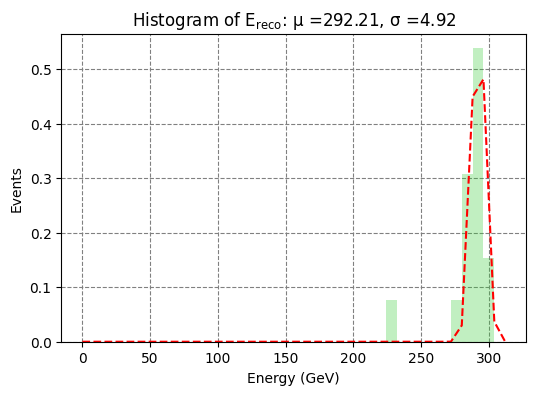

In [50]:
#set x-axis limits so that histogram is centered
xmin = 0
xmax = np.ceil(mu)*2

#plot histogram 
ax = df_ci_n.plot('n_hits', 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'Histogram of $\mathregular{E_{reco}}$: μ ='+str(np.round(mu,2))+', σ ='+str(np.round(std,2)),
        ylabel = 'Events', 
        xlabel='Energy (GeV)',
        rot = 0,
        color='limegreen',
        legend = None,
        figsize=(6, 4),
        alpha=0.3)

#plot gaussian fit
ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
#ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
#ax.get_figure().savefig('energy-distribution-'+root_file+'_noise-'+str(noise)+'_signal'+str(cluster_n)+'.png', bbox_inches = 'tight')

In [51]:
print(std/mu, std/300)

0.016850931269536972 0.01641321320718012
